# 1.Import Required Libraries

In [1]:

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - baseline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Advanced additions (for upgraded version)
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import GradientBoostingRegressor
import xgboost as xgb
from sklearn.metrics import mean_absolute_percentage_error



# 2.Load Uber Trip Dataset #


In [2]:
uber=pd.read_csv("/content/Uber-Jan-Feb-FOIL.csv")


# 3.Preview Dataset


In [3]:
# Preview the first few rows
print(uber.head())




  dispatching_base_number      date  active_vehicles  trips
0                  B02512  1/1/2015              190   1132
1                  B02765  1/1/2015              225   1765
2                  B02764  1/1/2015             3427  29421
3                  B02682  1/1/2015              945   7679
4                  B02617  1/1/2015             1228   9537


In [4]:
# Check the structure and data types
print(uber.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354 entries, 0 to 353
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   dispatching_base_number  354 non-null    object
 1   date                     354 non-null    object
 2   active_vehicles          354 non-null    int64 
 3   trips                    354 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 11.2+ KB
None


In [5]:

# Summary statistics
print(uber.describe())



       active_vehicles         trips
count       354.000000    354.000000
mean       1307.435028  11667.316384
std        1162.510626  10648.284865
min         112.000000    629.000000
25%         296.750000   2408.500000
50%        1077.000000   9601.000000
75%        1417.000000  13711.250000
max        4395.000000  45858.000000


# 4.Check for Missing Values

In [6]:

# Check for missing values
print(uber.isnull().sum())

dispatching_base_number    0
date                       0
active_vehicles            0
trips                      0
dtype: int64


# 5.Convert 'date' Column to Datetime Format #


In [7]:
# Convert 'date' column to datetime format
uber['date'] = pd.to_datetime(uber['date'])


In [8]:
# Check the updated data types
print(uber.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354 entries, 0 to 353
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   dispatching_base_number  354 non-null    object        
 1   date                     354 non-null    datetime64[ns]
 2   active_vehicles          354 non-null    int64         
 3   trips                    354 non-null    int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 11.2+ KB
None


# 6.Feature Engineering – Date-Based Attributes #


In [9]:
#Step 2: Feature Engineering + EDA
# Extract features from the 'date' column
uber['day'] = uber['date'].dt.day              # Day of the month (1–31)
uber['month'] = uber['date'].dt.month          # Month number (1–12)
uber['weekday'] = uber['date'].dt.dayofweek    # Day of week (Monday=0, Sunday=6)

# Create a weekend flag (1 = Saturday/Sunday, 0 = Weekday)
uber['weekend'] = (uber['weekday'] >= 5).astype(int)


# 7.Exploratory Data Analysis – Daily Trip Trends #


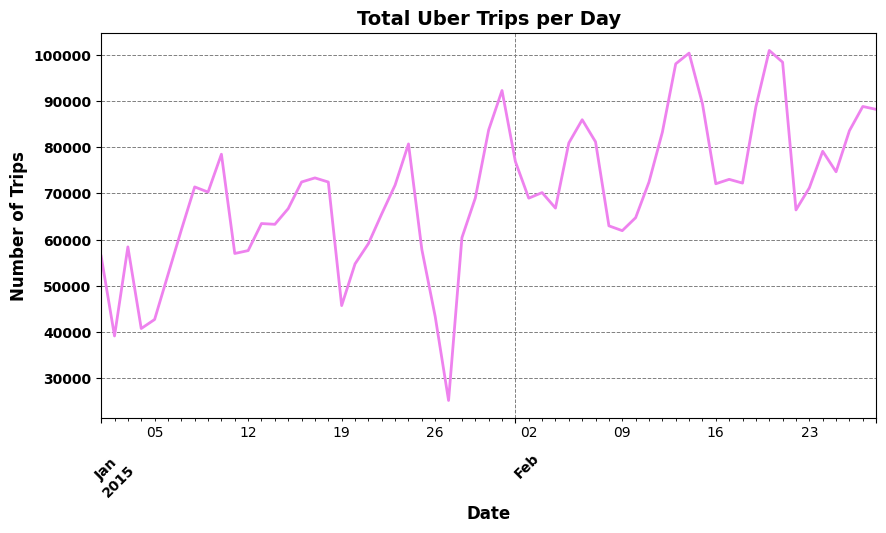

In [10]:
# Exploratory Data Analysis (EDA)
# 1. Total Trips per Day with bold black text, smaller chart, and violet line

daily_trips = uber.groupby('date')['trips'].sum()

plt.figure(figsize=(10,5))  # smaller chart size534
daily_trips.plot(color="violet", linewidth=2)  # violet line

# Bold black titles and labels
plt.title("Total Uber Trips per Day", fontsize=14, fontweight="bold", color="black")
plt.xlabel("Date", fontsize=12, fontweight="bold", color="black")
plt.ylabel("Number of Trips", fontsize=12, fontweight="bold", color="black")

# Bold black ticks
plt.xticks(rotation=45, fontsize=10, fontweight="bold", color="black")
plt.yticks(fontsize=10, fontweight="bold", color="black")

plt.grid(True, linestyle="--", linewidth=0.7, color="gray")
plt.show()


# 8.Trips vs Active Vehicles


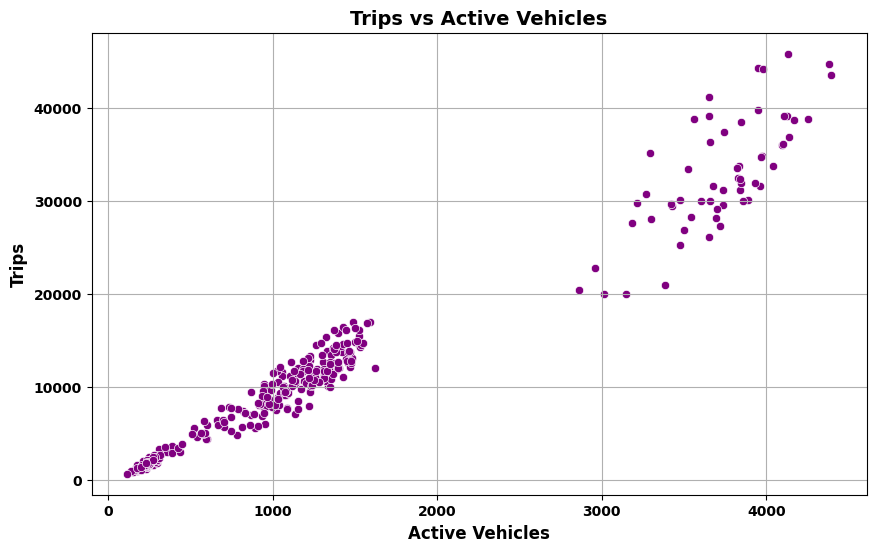

In [11]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=uber, x='active_vehicles', y='trips', color="purple")

plt.title("Trips vs Active Vehicles", fontsize=14, fontweight="bold", color="black")
plt.xlabel("Active Vehicles", fontsize=12, fontweight="bold", color="black")
plt.ylabel("Trips", fontsize=12, fontweight="bold", color="black")

plt.xticks(fontsize=10, fontweight="bold", color="black")
plt.yticks(fontsize=10, fontweight="bold", color="black")

plt.grid(True)
plt.show()


# 9.Weekday Trips

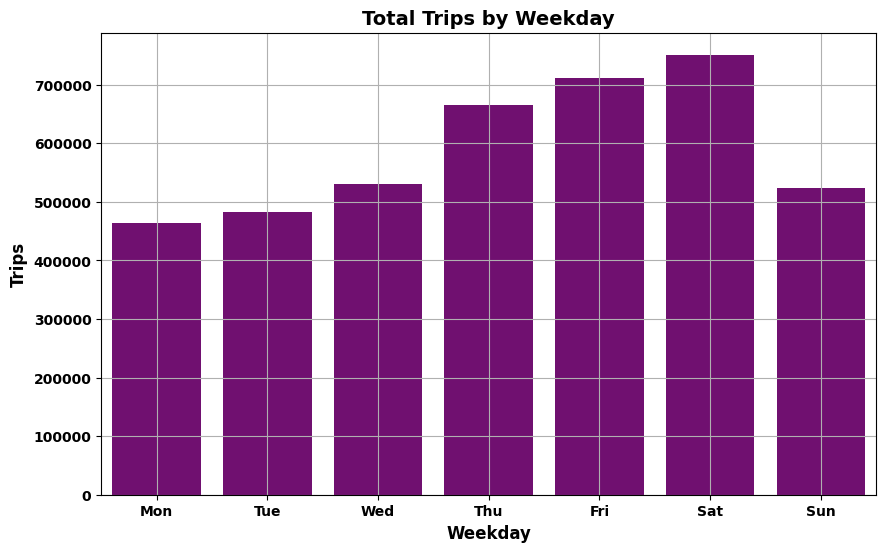

In [12]:
# Map weekday numbers to names
weekday_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
weekday_trips = uber.groupby('weekday')['trips'].sum()

plt.figure(figsize=(10,6))
sns.barplot(x=weekday_labels, y=weekday_trips.values, color="purple")

# Bold black titles and labels
plt.title("Total Trips by Weekday", fontsize=14, fontweight="bold", color="black")
plt.xlabel("Weekday", fontsize=12, fontweight="bold", color="black")
plt.ylabel("Trips", fontsize=12, fontweight="bold", color="black")

# Bold black ticks
plt.xticks(fontsize=10, fontweight="bold", color="black")
plt.yticks(fontsize=10, fontweight="bold", color="black")

plt.grid(True)
plt.show()


# 10.Weekend VS Weekday

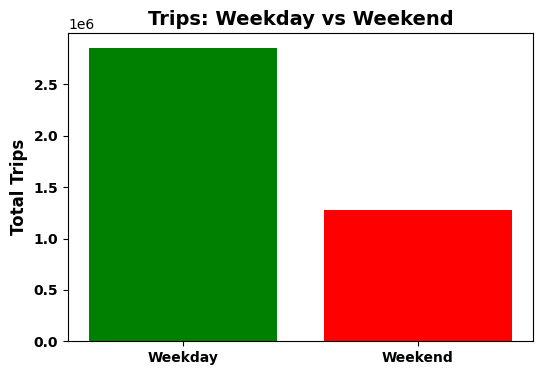

In [13]:
# Prepare data
weekend_trips = uber.groupby('weekend')['trips'].sum().reset_index()
weekend_trips['label'] = weekend_trips['weekend'].map({0: 'Weekday', 1: 'Weekend'})
weekend_trips['color'] = weekend_trips['weekend'].map({0: 'green', 1: 'red'})

# Plot
plt.figure(figsize=(6,4))
bars = plt.bar(weekend_trips['label'], weekend_trips['trips'], color=weekend_trips['color'])

# Bold black titles and labels
plt.title("Trips: Weekday vs Weekend", fontsize=14, fontweight="bold", color="black")
plt.ylabel("Total Trips", fontsize=12, fontweight="bold", color="black")

# Bold black ticks
plt.xticks(fontsize=10, fontweight="bold", color="black")
plt.yticks(fontsize=10, fontweight="bold", color="black")

plt.show()


# 11.Total Trips per Dispatching Base

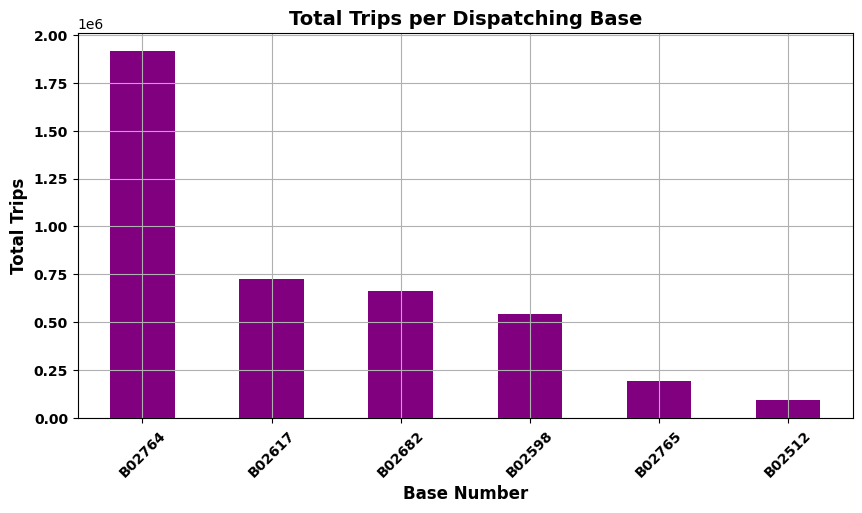

In [14]:
base_trips = uber.groupby('dispatching_base_number')['trips'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))  # smaller chart size
base_trips.plot(kind='bar', color='purple')

# Bold black titles and labels
plt.title("Total Trips per Dispatching Base", fontsize=14, fontweight="bold", color="black")
plt.xlabel("Base Number", fontsize=12, fontweight="bold", color="black")
plt.ylabel("Total Trips", fontsize=12, fontweight="bold", color="black")

# Bold black ticks
plt.xticks(rotation=45, fontsize=10, fontweight="bold", color="black")
plt.yticks(fontsize=10, fontweight="bold", color="black")

plt.grid(True)
plt.show()


# 12.Business Insights

- **Daily Trips Trend:** Trips steadily increase through the week, peaking on Saturday. Uber should ensure driver availability on weekends to meet demand.

- **Trips vs Active Vehicles:** Strong correlation between active vehicles and trips. Uber can forecast demand and adjust fleet size accordingly to reduce idle time and improve efficiency.

- **Trips by Weekday:** Saturday is the busiest single day, but weekdays dominate overall volume. Uber should prioritize weekday commuting demand while preparing for weekend leisure peaks.

- **Dispatching Base Analysis:** Base B02764 handles the highest trip volume, making it a key operational hub. Uber should prioritize resources, driver incentives, and support in this region, while reviewing strategies for lower-performing bases.


# 13.Model Training and Evaluation – Random Forest Regressor

In [15]:
# Train, predict, and evaluate (compatible with older scikit-learn)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Features and target
X = uber[['active_vehicles', 'weekday', 'weekend', 'month']]
y = uber['trips']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model training
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation (RMSE without 'squared' arg)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

# (Optional) Quick comparison table
comparison = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
print("\nSample predictions:\n", comparison.head(10))


RMSE: 1326.806348971587
R² Score: 0.9836741054681873

Sample predictions:
    Actual   Predicted
0   38693  39913.2900
1    1911   1863.8700
2    9463   9644.2400
3    1892   1722.6440
4   10287   9565.8300
5   14662  13195.0300
6    8010   8238.3000
7    1646   1571.3390
8    1608   1558.9775
9   31957  33461.8800


# 14.Model Evaluation – Actual vs Predicted Trips

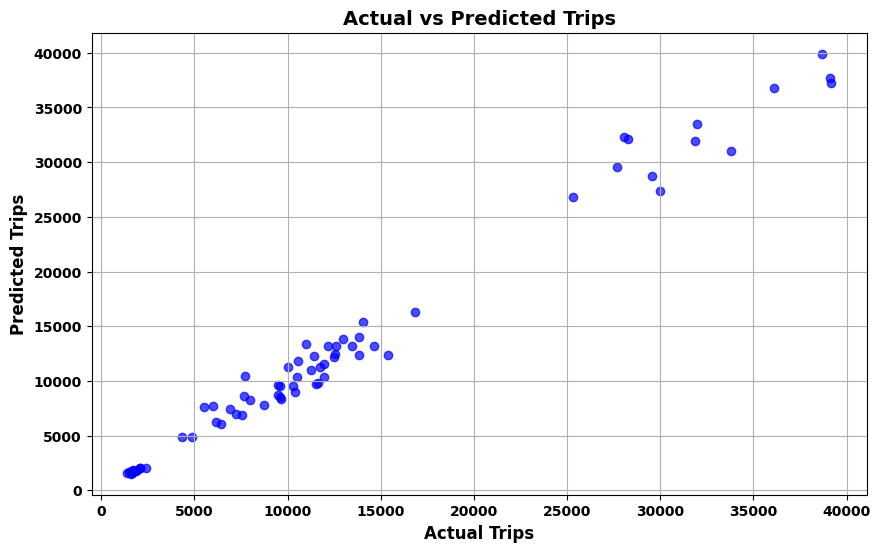

In [16]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.7, color='blue')

# Bold black titles and labels
plt.title("Actual vs Predicted Trips", fontsize=14, fontweight="bold", color="black")
plt.xlabel("Actual Trips", fontsize=12, fontweight="bold", color="black")
plt.ylabel("Predicted Trips", fontsize=12, fontweight="bold", color="black")

# Bold black ticks
plt.xticks(fontsize=10, fontweight="bold", color="black")
plt.yticks(fontsize=10, fontweight="bold", color="black")

plt.grid(True)
plt.show()


# 15.Feature Engineering – Lag and Rolling Features

In [17]:
# Lag features
uber['lag1'] = uber['trips'].shift(1)
uber['lag7'] = uber['trips'].shift(7)
uber['rolling7'] = uber['trips'].rolling(7).mean()


In [18]:
tscv = TimeSeriesSplit(n_splits=5)


# 16.Model Comparison – Random Forest vs Gradient Boosting vs XGBoost

In [19]:
from sklearn.ensemble import GradientBoostingRegressor
import xgboost as xgb

# --- Random Forest ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_rmse = mean_squared_error(y_test, rf_pred) ** 0.5
rf_r2 = r2_score(y_test, rf_pred)

# --- Gradient Boosting ---
gbr_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gbr_model.fit(X_train, y_train)
gbr_pred = gbr_model.predict(X_test)
gbr_rmse = mean_squared_error(y_test, gbr_pred) ** 0.5
gbr_r2 = r2_score(y_test, gbr_pred)

# --- XGBoost ---
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_rmse = mean_squared_error(y_test, xgb_pred) ** 0.5
xgb_r2 = r2_score(y_test, xgb_pred)

# --- Comparison Table ---
results = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting', 'XGBoost'],
    'RMSE': [rf_rmse, gbr_rmse, xgb_rmse],
    'R²': [rf_r2, gbr_r2, xgb_r2]
})
print(results)


               Model         RMSE        R²
0      Random Forest  1326.806349  0.983674
1  Gradient Boosting  1439.535569  0.980782
2            XGBoost  1659.455558  0.974462


In [20]:
# Weighted average ensemble (weights based on R² scores)
weights = np.array([rf_r2, gbr_r2, xgb_r2]) / (rf_r2 + gbr_r2 + xgb_r2)
ensemble_pred = (weights[0]*rf_pred + weights[1]*gbr_pred + weights[2]*xgb_pred)

ensemble_rmse = mean_squared_error(y_test, ensemble_pred) ** 0.5
ensemble_r2 = r2_score(y_test, ensemble_pred)

print("Ensemble RMSE:", ensemble_rmse)
print("Ensemble R²:", ensemble_r2)


Ensemble RMSE: 1356.0710838750758
Ensemble R²: 0.9829459781401124


# 17.Model Performance Comparison – Random Forest, Gradient Boosting, XGBoost, and Ensemble


In [21]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting', 'XGBoost', 'Ensemble'],
    'RMSE': [rf_rmse, gbr_rmse, xgb_rmse, ensemble_rmse],
    'R²': [rf_r2, gbr_r2, xgb_r2, ensemble_r2]
})
print(results)


               Model         RMSE        R²
0      Random Forest  1326.806349  0.983674
1  Gradient Boosting  1439.535569  0.980782
2            XGBoost  1659.455558  0.974462
3           Ensemble  1356.071084  0.982946


# 18.Model Predictions vs Actual Trips – Performance Comparison

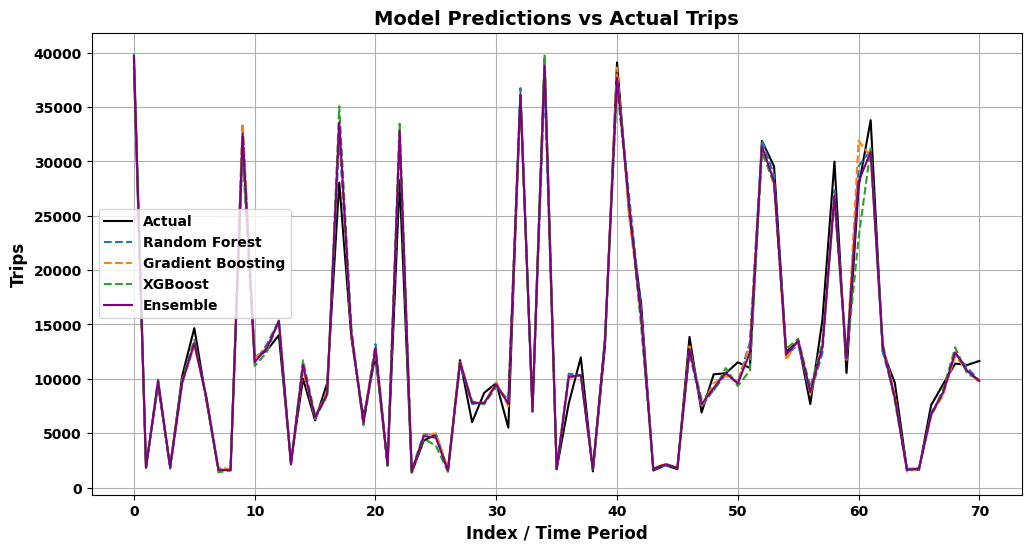

In [22]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual', color='black')
plt.plot(rf_pred, label='Random Forest', linestyle='--')
plt.plot(gbr_pred, label='Gradient Boosting', linestyle='--')
plt.plot(xgb_pred, label='XGBoost', linestyle='--')
plt.plot(ensemble_pred, label='Ensemble', color='purple')

# Bold black legend
plt.legend(fontsize=10, prop={'weight':'bold'}, labelcolor='black')

# Bold black title and labels
plt.title("Model Predictions vs Actual Trips", fontsize=14, fontweight="bold", color="black")
plt.xlabel("Index / Time Period", fontsize=12, fontweight="bold", color="black")
plt.ylabel("Trips", fontsize=12, fontweight="bold", color="black")

# Bold black ticks
plt.xticks(fontsize=10, fontweight="bold", color="black")
plt.yticks(fontsize=10, fontweight="bold", color="black")

plt.grid(True)
plt.show()


# 19.Residuals vs Actual Trips – Error Analysis Across Models

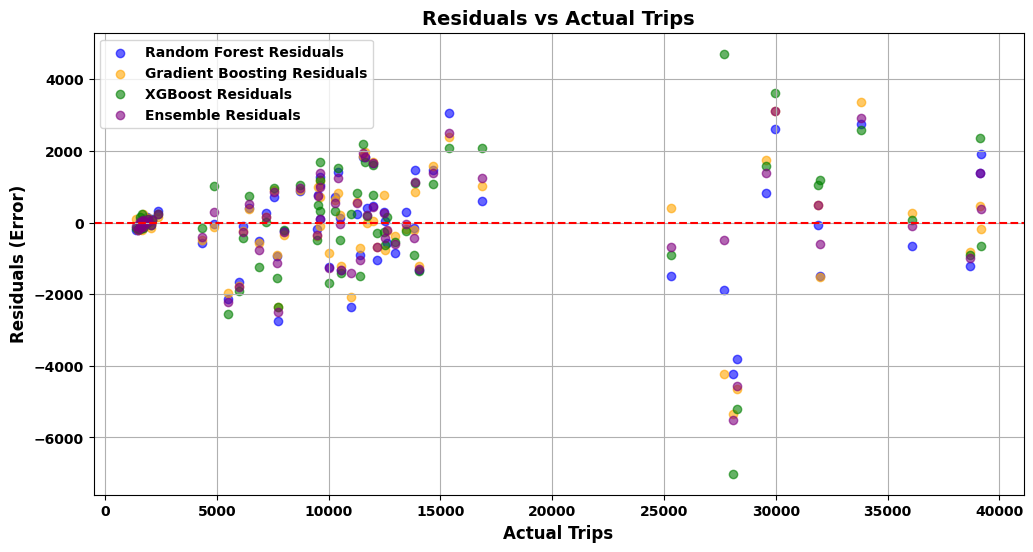

In [23]:
# Residuals (Actual - Predicted) for each model
rf_residuals = y_test - rf_pred
gbr_residuals = y_test - gbr_pred
xgb_residuals = y_test - xgb_pred
ensemble_residuals = y_test - ensemble_pred

plt.figure(figsize=(12,6))

plt.scatter(y_test, rf_residuals, alpha=0.6, label='Random Forest Residuals', color='blue')
plt.scatter(y_test, gbr_residuals, alpha=0.6, label='Gradient Boosting Residuals', color='orange')
plt.scatter(y_test, xgb_residuals, alpha=0.6, label='XGBoost Residuals', color='green')
plt.scatter(y_test, ensemble_residuals, alpha=0.6, label='Ensemble Residuals', color='purple')

plt.axhline(0, color='red', linestyle='--')

# Bold black titles and labels
plt.title("Residuals vs Actual Trips", fontsize=14, fontweight="bold", color="black")
plt.xlabel("Actual Trips", fontsize=12, fontweight="bold", color="black")
plt.ylabel("Residuals (Error)", fontsize=12, fontweight="bold", color="black")

# Bold black ticks
plt.xticks(fontsize=10, fontweight="bold", color="black")
plt.yticks(fontsize=10, fontweight="bold", color="black")

# Bold black legend
plt.legend(fontsize=10, prop={'weight':'bold'}, labelcolor='black')

plt.grid(True)
plt.show()


# 20.Residuals Histogram – Error Distribution Across Models

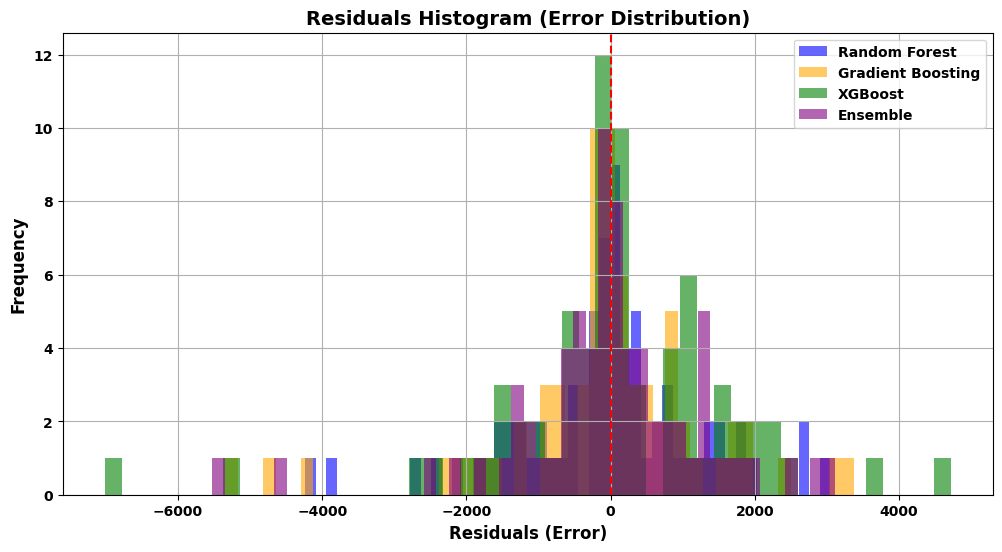

In [24]:

# Residuals for each model
rf_residuals = y_test - rf_pred
gbr_residuals = y_test - gbr_pred
xgb_residuals = y_test - xgb_pred
ensemble_residuals = y_test - ensemble_pred

# --- Residual Histogram ---
plt.figure(figsize=(12,6))
plt.hist(rf_residuals, bins=50, alpha=0.6, label='Random Forest', color='blue')
plt.hist(gbr_residuals, bins=50, alpha=0.6, label='Gradient Boosting', color='orange')
plt.hist(xgb_residuals, bins=50, alpha=0.6, label='XGBoost', color='green')
plt.hist(ensemble_residuals, bins=50, alpha=0.6, label='Ensemble', color='purple')

plt.axvline(0, color='red', linestyle='--')

# Bold black titles and labels
plt.title("Residuals Histogram (Error Distribution)", fontsize=14, fontweight="bold", color="black")
plt.xlabel("Residuals (Error)", fontsize=12, fontweight="bold", color="black")
plt.ylabel("Frequency", fontsize=12, fontweight="bold", color="black")

# Bold black ticks
plt.xticks(fontsize=10, fontweight="bold", color="black")
plt.yticks(fontsize=10, fontweight="bold", color="black")

# Bold black legend
plt.legend(fontsize=10, prop={'weight':'bold'}, labelcolor='black')

plt.grid(True)
plt.show()


# 21. Residuals Boxplot – Error Spread Across Models

/tmp/ipykernel_1576/3928244030.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([rf_residuals, gbr_residuals, xgb_residuals, ensemble_residuals],


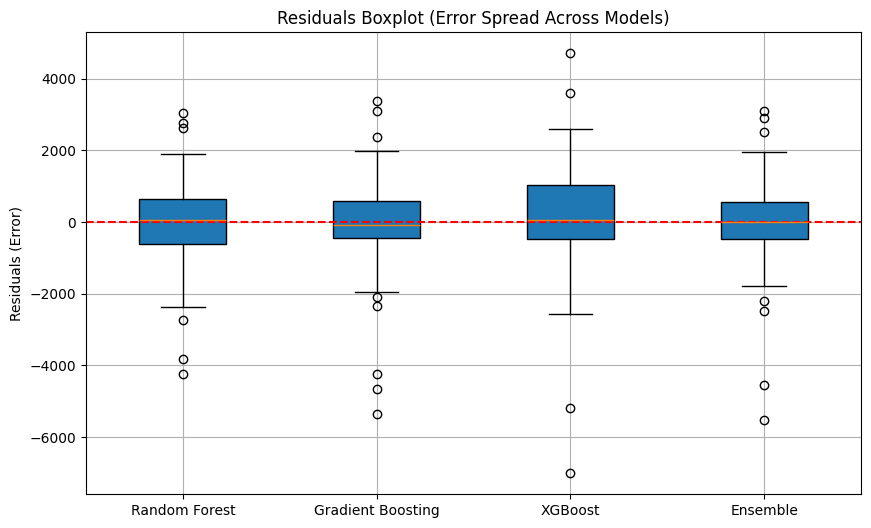

In [25]:
# --- Residual Boxplot ---
plt.figure(figsize=(10,6))
plt.boxplot([rf_residuals, gbr_residuals, xgb_residuals, ensemble_residuals],
            labels=['Random Forest', 'Gradient Boosting', 'XGBoost', 'Ensemble'],
            patch_artist=True)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals Boxplot (Error Spread Across Models)")
plt.ylabel("Residuals (Error)")
plt.grid(True)
plt.show()


/tmp/ipykernel_1576/3801970696.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([rf_residuals, gbr_residuals, xgb_residuals, ensemble_residuals],


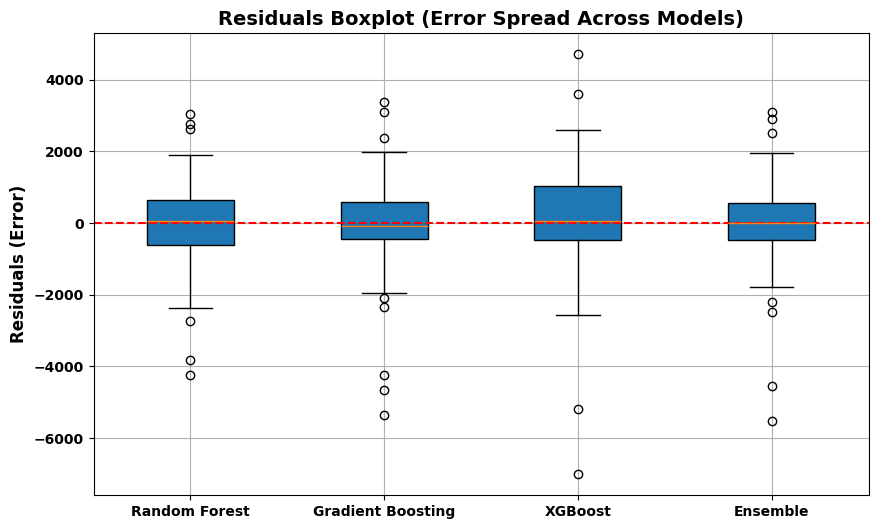

In [26]:
# --- Residual Boxplot ---
plt.figure(figsize=(10,6))
plt.boxplot([rf_residuals, gbr_residuals, xgb_residuals, ensemble_residuals],
            labels=['Random Forest', 'Gradient Boosting', 'XGBoost', 'Ensemble'],
            patch_artist=True)

plt.axhline(0, color='red', linestyle='--')

# Bold black titles and labels
plt.title("Residuals Boxplot (Error Spread Across Models)", fontsize=14, fontweight="bold", color="black")
plt.ylabel("Residuals (Error)", fontsize=12, fontweight="bold", color="black")

# Bold black ticks
plt.xticks(fontsize=10, fontweight="bold", color="black")
plt.yticks(fontsize=10, fontweight="bold", color="black")

plt.grid(True)
plt.show()


# 22.Feature Importance – SHAP Summary Plot (Random Forest)

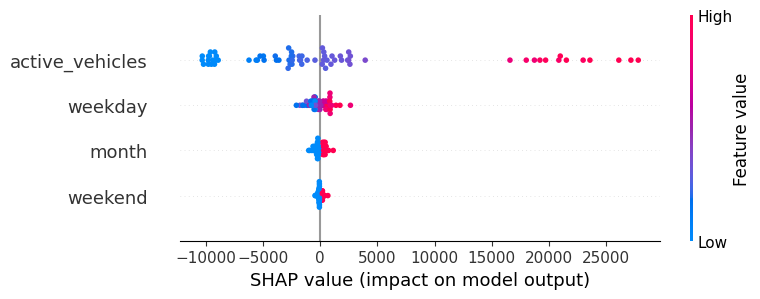

In [27]:
import shap

# Initialize SHAP explainer for Random Forest
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# --- SHAP Summary Plot ---
shap.summary_plot(shap_values, X_test)


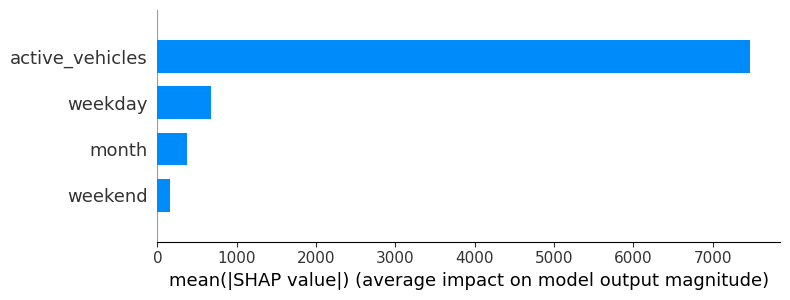

In [28]:

# --- SHAP Feature Importance Bar Plot ---
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [29]:

uber.to_csv("uber_clean.csv", index=False)
from google.colab import files
files.download("uber_clean.csv")




<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion

- Demand is higher on weekends
- Active vehicles strongly impact trips
- Gradient Boosting performed best model
- Model can help Uber in demand forecasting